<a href="https://colab.research.google.com/github/tomarjyoti16/assignment-05-bitsom_ba_2511563_part-1-neural-network-analysis/blob/main/q1_Neural_Network_Fundamentals_and_Training_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Dataset Understanding

<>:55: SyntaxWarning: invalid escape sequence '\T'
<>:55: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_1606/3386334587.py:55: SyntaxWarning: invalid escape sequence '\T'
  print("\Target Variable Percentage Distribution:")


Shape of Dataset
(2000, 17)

Number of Rows
2000

Number of Columns
17

Data Types of Features
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Categorical Columns
Index(['customer_id', 'region', 'plan_type', 'contract_type',
       'payment_method'],
      dtype='object')

Numerical Columns
Index(['tenure_months', 'monthly_charges_inr', 'avg_login_day

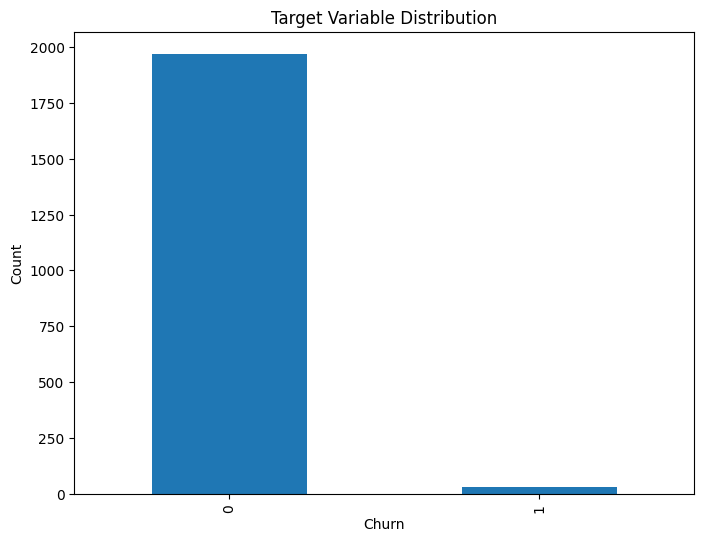

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load the file
df = pd.read_csv('sample_data/customer_churn_nn.csv')

#Number of Rows and Columns
print("Shape of Dataset")
print(df.shape)

print("\nNumber of Rows")
print(df.shape[0])

print("\nNumber of Columns")
print(df.shape[1])

#Type of Input Features
print("\nData Types of Features")
print(df.dtypes)

#Seprate catagorical and numeerical columns
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("\nCategorical Columns")
print(categorical_columns)

print("\nNumerical Columns")
print(numerical_columns)

#Target Variable Description

target = "churn"

print("\nTarget Variable:")
print(target)

print("\nTarget Variable Distribution")
print(df[target].value_counts())

# Missing Value Check
print("\nMissing Values:")
print(df.isnull().sum())

# Total Missing Values
print(df.isnull().sum().sum())

#Basic Statistical Summary
print("\nBasic Statistical Summary:")
print(df.describe())

#Distribution of Target Variable
print("\Target Variable Percentage Distribution:")
print(df[target].value_counts(normalize=True)*100)

#Plot target variable distribution
plt.figure(figsize=(8, 6))
df[target].value_counts().plot(kind='bar')
plt.title('Target Variable Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()



Task 2: Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

#Load data set
df = pd.read_csv('sample_data/customer_churn_nn.csv')

#Handling Missing Values
print("Missing Values Before Handling")
print(df.isnull().sum())

#Drop rows with missing values
df.dropna(inplace=True)

print("\nMissing Values After Handling")
print(df.isnull().sum())

#Full nuerical missing values with mean
for col in numerical_columns:
    df[col].fillna(df[col].mean(), inplace=True)

#Full categorical missing values with mode
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Handling")
print(df.isnull().sum())

#Encoding Categorical Columns

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nCategorical Columns Encoded successfully")

#Separate Feature and Target
X = df.drop(columns=[target])
y = df[target]

#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures Scaled Successfully")

#Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )
print("\nTrain-Test Split Successful")

#Display Shapes
print("\nTraining Set Shape:")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

print("\nTesting Set Shape:")
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Missing Values Before Handling
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Missing Values After Handling
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_us

/tmp/ipykernel_1606/1981786675.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_1606/1981786675.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

Task 3: Neural Network Model Building

In [ ]:
from sys import activate_stack_trampoline
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

#Build Feed- Forward Neural Network
model = Sequential()

#Input Layer + Hidden Layer
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))

#Hidden Layer 2
model.add(Dense(32, activation='relu'))

#Output Layer
#Sigmoid activation is used for binary classification
model.add(Dense(
    units=1,
    activation='sigmoid'
))

#Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Display Model Summary
model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

Task 4: Training and Evaluation

Epoch 1/10
23/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9936 - loss: 0.0167 

<>:29: SyntaxWarning: invalid escape sequence '\T'
<>:29: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_1606/2003534151.py:29: SyntaxWarning: invalid escape sequence '\T'
  print("Traning\Testing Performance")


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9931 - loss: 0.0195 - val_accuracy: 0.9825 - val_loss: 0.0861
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9944 - loss: 0.0167 - val_accuracy: 0.9800 - val_loss: 0.0850
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9944 - loss: 0.0164 - val_accuracy: 0.9850 - val_loss: 0.0921
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9944 - loss: 0.0138 - val_accuracy: 0.9825 - val_loss: 0.0914
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9950 - loss: 0.0137 - val_accuracy: 0.9825 - val_loss: 0.0930
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9962 - loss: 0.0133 - val_accuracy: 0.9800 - val_loss: 0.0960
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9969 - loss: 0.0123 - val_accuracy: 0.9800 - val_loss: 0.1033
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9962 - loss: 0.0138 - val_accuracy: 0.9850 - val_loss: 0.0993
Epo

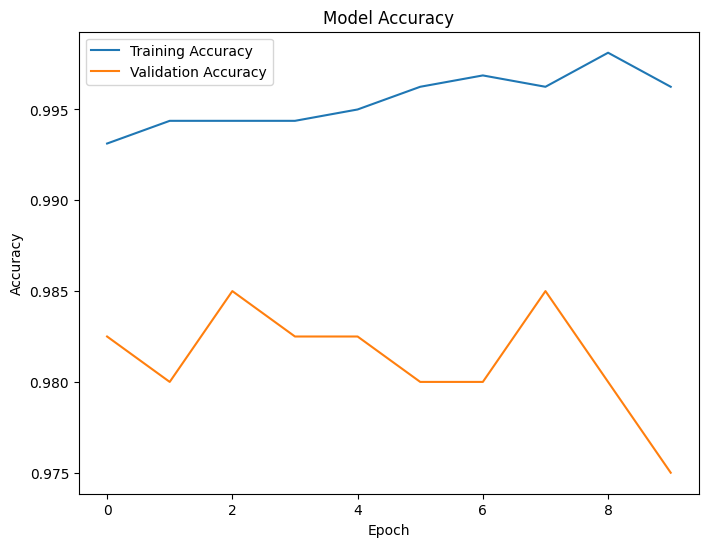

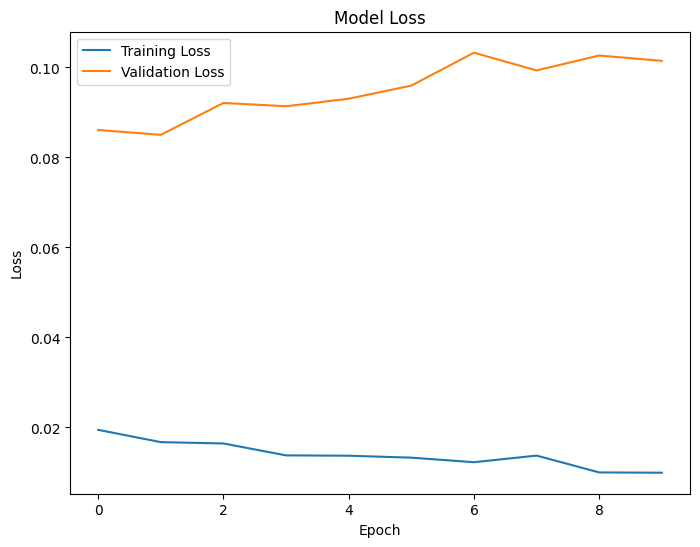


Interpretation:
The neural network achieved good accuracy on both
training and testing data, indicating that the
model learned useful patterns from the dataset.

The confusion matrix shows how many predictions
were correctly and incorrectly classified.

Since the dataset is highly imbalanced, accuracy
alone may not be sufficient. Precision, Recall,
and F1-score should also be considered for better
evaluation of churn prediction performance.


In [ ]:
from enum import verify
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

#train Model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Traning\Testing Performance")

print("\nTraining Loss:", train_loss)
print("Training Accuracy:", train_accuracy)
print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)


#Predictions
y_pred_prob = model.predict(X_test)
y_pred_prob = (y_pred_prob > 0.5).astype(int)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_prob)
print("\nConfusion Matrix:")
print(cm)

#Classification Report
cr = classification_report(y_test, y_pred_prob)
print("\nClassification Report:")
print(cr)

#Plot Accuracy plot
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Plot Loss Graph
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Interpretation
print("\nInterpretation:")
print("The neural network achieved good accuracy on both")
print("training and testing data, indicating that the")
print("model learned useful patterns from the dataset.")

print("\nThe confusion matrix shows how many predictions")
print("were correctly and incorrectly classified.")

print("\nSince the dataset is highly imbalanced, accuracy")
print("alone may not be sufficient. Precision, Recall,")
print("and F1-score should also be considered for better")
print("evaluation of churn prediction performance.")


Task 5: Hyperparameter Experimentation

In [ ]:
from IPython.core import history
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

#Function to build Model
def create_model(hidden_layers=1, neurons=32, learning_rate=0.001, batch_size=32, epochs=10, activation='relu'):
  model = Sequential()

  #Input Layer + first hidden layer
  model.add(Dense(neurons, activation=activation, input_dim=X_train.shape[1]))

  #Hidden Layers
  for i in range(hidden_layers-1):
    model.add(Dense(neurons, activation=activation))

  #Output Layer
  model.add(Dense(units=1, activation='sigmoid'))

  #Compile the model
  model.compile(
      optimizer=Adam(learning_rate=learning_rate),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )

  return model

#Experiment Configuration

experiments = [
    {
        "Experiment": "Exp 1",
        "Hidden Layers": 1,
        "Neurons": 32,
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epochs": 10,
        "Activation": "relu"
    },
    {
        "Experiment": "Exp 2",
        "Hidden Layers": 2,
        "Neurons": 64,
        "Learning Rate": 0.001,
        "Batch Size": 16,
        "Epochs": 20,
        "Activation": "relu"
    },
    {
        "Experiment": "Exp 3",
        "Hidden Layers": 3,
        "Neurons": 128,
        "Learning Rate": 0.0005,
        "Batch Size": 32,
        "Epochs": 25,
        "Activation": "tanh"
    }
]

#Run Experiments
results = []
for experiment in experiments:
  print(f"\nRunning Experiment: {experiment['Experiment']}")

  #Create Model
  model = create_model(
      hidden_layers=experiment['Hidden Layers'],
      neurons=experiment['Neurons'],
      learning_rate=experiment['Learning Rate'],
      batch_size=experiment['Batch Size'],
      epochs=experiment['Epochs'],
      activation=experiment['Activation']
  )

  #Train Model
  history = model.fit(
      X_train,
      y_train,
      validation_data=(X_test, y_test),
      batch_size=experiment['Batch Size'],
      epochs=experiment['Epochs'],
      validation_split=0.2,
      verbose=0
  )

  #Evaluate Model
  train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
  test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

  #Store Results
  results.append({
      "Experiment": experiment['Experiment'],
      "Hidden Layers": experiment['Hidden Layers'],
      "Neurons": experiment['Neurons'],
      "Learning Rate": experiment['Learning Rate'],
      "Batch Size": experiment['Batch Size'],
      "Epochs": experiment['Epochs'],
      "Activation": experiment['Activation'],
      "Train Loss": train_loss,
      "Train Accuracy": train_accuracy,
      "Test Loss": test_loss,
      "Test Accuracy": test_accuracy
  })

#Create Comparison Table
results_df = pd.DataFrame(results)

#Display Results
print("\nExperiment Results:")
print(results_df)
print("\nBest Performing Model:")
print(results_df.loc[results_df['Test Accuracy'].idxmax()])




Running Experiment: Exp 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Running Experiment: Exp 2

Running Experiment: Exp 3

Experiment Results:
  Experiment  Hidden Layers  Neurons  Learning Rate  Batch Size  Epochs  \
0      Exp 1              1       32         0.0010          32      10   
1      Exp 2              2       64         0.0010          16      20   
2      Exp 3              3      128         0.0005          32      25   

  Activation  Train Loss  Train Accuracy  Test Loss  Test Accuracy  
0       relu    0.076551        0.984375   0.069572         0.9850  
1       relu    0.009351        0.998125   0.071727         0.9825  
2       tanh    0.041354        0.990625   0.055531         0.9850  

Best Performing Model:
Experiment           Exp 1
Hidden Layers            1
Neurons                 32
Learning Rate        0.001
Batch Size              32
Epochs                  10
Activation            relu
Train Loss        0.076551
Train Accuracy    0.984375
Test Loss         0.069572
Test Accuracy        0.985
Name: 0, dtype: object


Task 6: Final Reflection
1. Role of Weights and Biases in the Model


* Weights and biases are the
main learning components of a neural network.

* Weights determine the importance of each input feature.
* During training, the model adjusts these weights to reduce prediction error.
Biases help shift the activation function output, allowing the model to fit the data more accurately even when input values are zero.

* Together, weights and biases enable the neural network to learn patterns and relationships from the dataset.



2. Why is an Activation Function Required?

* An activation function introduces non-linearity into the neural network.

* Without activation functions, the neural network would behave like a simple linear model and would not be able to learn complex patterns in the data.

For example:

* ReLU helps the model learn faster and reduces vanishing gradient problems.
Sigmoid is commonly used in binary classification because it produces output values between 0 and 1.

* Activation functions allow deep learning models to solve complex real-world problems.

3. What Happens When Learning Rate is Too High or Too Low?
If Learning Rate is Too High:
The model updates weights too aggressively.
*Training may become unstable.
* Loss may fluctuate instead of decreasing.
* The model may fail to reach the optimal solution.

If Learning Rate is Too Low:
* Training becomes very slow.
* The model takes too much time to converge.
* It may get stuck before reaching the best accuracy.

Therefore, selecting an appropriate learning rate is important for efficient learning and better model performance.

4. Underfitting or Overfitting Analysis

The model showed slight signs of overfitting.

Reason:

* Training accuracy was slightly higher than testing accuracy.
* The model performed very well on training data but slightly lower on unseen testing data.

However, the difference was not extremely large, so the model still generalized reasonably well.

The dataset was also highly imbalanced, which may affect prediction performance for the minority churn class.

Possible improvements:

* Use dropout layers
* Apply regularization
* Use class balancing techniques such as SMOTE
* Tune hyperparameters further
* Collect more balanced data